In [2]:
import pandas as pd
import scanpy as sc

In [5]:
adata = sc.read("/rds/general/user/ao225/home/CardiaFinal/Data/Post_Processed/Science/LVCardio.h5ad")
umap = pd.read_csv("/rds/general/user/ao225/home/CardiaFinal/Results/Science/lv_umap.csv")  
auc  = pd.read_csv("/rds/general/user/ao225/home/CardiaFinal/Results/SCENIC/SCENIC_results/lv_auc_mtx.csv", index_col=0)

In [6]:
umap["cell"] = umap["cell"].astype(str)    
umap = umap.set_index("cell")  
auc.index = auc.index.astype(str)
auc = auc.reindex(adata.obs_names)

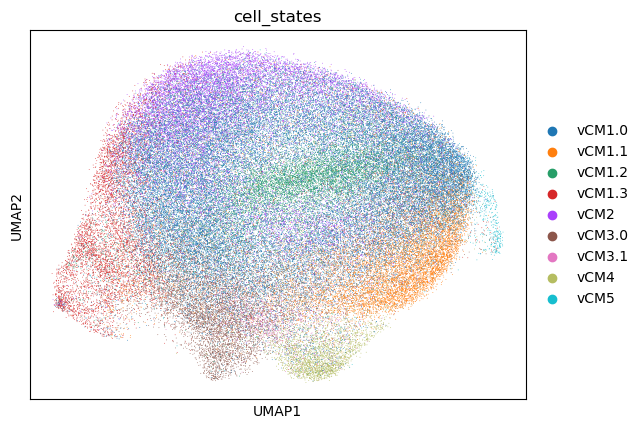

In [7]:
adata.obsm["X_umap_old"] = adata.obsm["X_umap"].copy()
umap_aligned = umap.reindex(adata.obs_names)
adata.obsm["X_umap"] = umap_aligned[["umap_1","umap_2"]].values
sc.pl.umap(adata, color="cell_states")

In [8]:
regulons = auc.columns.tolist()
adata.obsm["AUCell"] = auc.values
adata.uns["regulons"] = regulons

In [12]:
adata.write_h5ad("/rds/general/user/ao225/home/CardiaFinal/Data/Post_Processed/Science/NewCardiac.h5ad")

In [9]:
adata.raw.X[:5, :20].toarray()

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
        0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.]], dtype=float32)

In [10]:
assert (auc.index == adata.obs_names).all(), "ORDER MISMATCH — reindex first!"

In [3]:
adata = sc.read_h5ad("/rds/general/user/ao225/home/CardiaFinal/Data/Post_Processed/Science/NewCardiac.h5ad")

In [11]:
print("Same cells?", set(auc.index) == set(adata.obs_names))
print("First 10 AnnData:", list(adata.obs_names[:10]))
print("First 10 AUCell:", list(auc.index[:10]))


Same cells? True
First 10 AnnData: ['3350', '3351', '3352', '3353', '3354', '3355', '3356', '3357', '3358', '3359']
First 10 AUCell: ['3350', '3351', '3352', '3353', '3354', '3355', '3356', '3357', '3358', '3359']


In [8]:
auc.index = auc.index.astype(str)
